<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/3_1_agrupamiento_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1: Aprendizaje no Supervisado - Clustering

En este ejercicio se aplican técnicas de clustering (como KMeans y DBSCAN) a diferentes datasets sinteticos. Completa las secciones indicadas y analiza los resultados obtenidos para evaluar la eficiencia de cada método.

Además, encontrarás partes del código contendrán  el comentario de `# ACTIVIDAD` que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique. Finalmente, en el final de este ejercicio, deberás responder a una serie de preguntas.

## Importar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.cluster import calinski_harabasz_score
from sklearn.datasets import make_moons, make_circles, make_blobs, make_classification
from sklearn.cluster import KMeans, DBSCAN

In [ ]:
# Aseguramos que los resultados sean reproducibles
np.random.seed(0)

# Carga de Datos

In [ ]:
datasets = {
    "moons": make_moons(n_samples=1000, noise=0.1, random_state=0),
    "circles": make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=0),
    "blobs": make_blobs(
        n_samples=1000, centers=[(-1, -1), (1, 1)], cluster_std=0.5, random_state=0
    ),
    "lines": make_classification(
        n_samples=1000,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=0,
    ),
}

In [ ]:
# ACTIVIDAD: Escoger el dataset a probar
X, y = datasets["lines"]

# Entrenamiento de los modelos de clustering

In [ ]:
kmeans = KMeans(n_clusters=2)
y_kmeans = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=10, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Evaluación de los resultados

In [ ]:
models = {"Kmeans": y_kmeans, "Dbscan": y_dbscan}
for name, y_pred in models.items():
    if len(np.unique(y_pred)) < 2:
        score = float("inf")
    else:
        score = calinski_harabasz_score(X, y_pred)
    print(f"Silhouette score for {name}: {score:.2f}")

Silhouette score for Kmeans: 848.64
Silhouette score for Dbscan: inf


# Visualización de los resultados

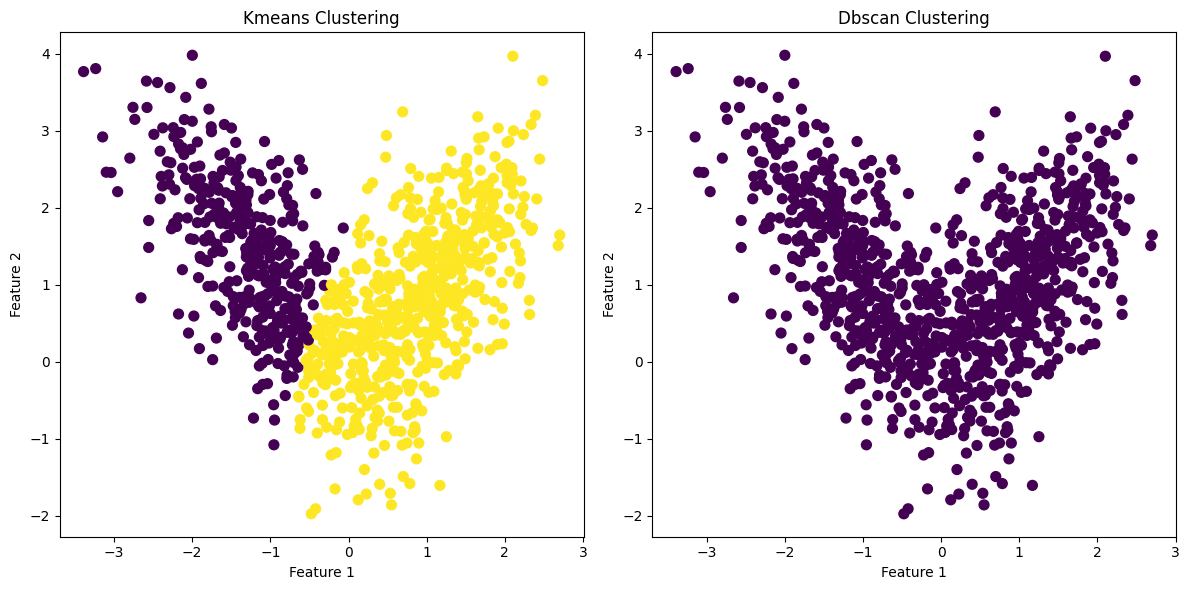

In [ ]:
# Visualizacion de la seleccion cluster
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for ax, (name, y_pred) in zip(axs.flatten(), models.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y_pred, s=50, cmap="viridis")
    ax.set_title(f"{name} Clustering")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [ ]:
models = [
    KMeans(n_clusters=2),
    KMeans(n_clusters=3),
    KMeans(n_clusters=4, init="random"),
    KMeans(n_clusters=4, init="k-means++"),
    KMeans(n_clusters=4, n_init=1),
    DBSCAN(eps=0.3, min_samples=5),
    DBSCAN(eps=0.5, min_samples=5),
    DBSCAN(eps=0.5, min_samples=10),
    DBSCAN(eps=0.7, min_samples=5),
    DBSCAN(eps=1.0, min_samples=2),
]

for m in models:
    y_pred = m.fit_predict(X)

    if len(np.unique(y_pred)) < 2:
        score = float("inf")
    else:
        score = calinski_harabasz_score(X, y_pred)

    # Print the same init parameter for model
    print(f"{score:.2f}, ", end="")

848.64, 1134.64, 1120.30, 1120.27, 1120.29, 16.31, 11.72, 22.89, 6.51, inf, 

# Preguntas

- ¿Cuáles son los mejores hiperparámetros que has encontrado para agrupar cada dataset? Prueba con al menos las siguientes configuraciones:
  - 'KMeans(n_clusters=2)'
  - 'KMeans(n_clusters=3)'
  - 'KMeans(n_clusters=4, init='random')'
  - 'KMeans(n_clusters=4, init='k-means++')'
  - 'KMeans(n_clusters=4, n_init=1)'
  - 'DBSCAN(eps=0.3, min_samples=5)'
  - 'DBSCAN(eps=0.5, min_samples=5)'
  - 'DBSCAN(eps=0.5, min_samples=10)'
  - 'DBSCAN(eps=0.7, min_samples=5)'
  - 'DBSCAN(eps=1.0, min_samples=2)'

  * Resultados en orden:
    * Moons: 1451.27, 1314.06, 1504.82, 1504.82, 1504.67, inf, inf, inf, inf, inf
    * Circles: 557.07, 787.07, 864.92, 859.15, 859.30, inf, inf, inf, inf, inf
    * Blobs: 4301.80, 2690.61, 2286.91, 2120.54, 2268.67, 1978.92, 6.85, 3.37, inf, inf
    * Lines: 848.64, 1134.64, 1120.30, 1120.27, 1120.29, 16.31, 11.72, 22.89, 6.51, inf

- ¿Qué dataset es más fácil de separar? ¿Por qué?
  * Blobs es el más fácil de separar, ya que los puntos se pueden separar claramente en grupos de forma lineal. Mientras que los otros datasets tienen formas más complejas y no lineales.

- ¿Cómo encontrarías el hiperparámetro k de kmeans si no supieras el número de clústeres?
  * Probando diferentes valores de k y evaluando la calidad del clustering utilizando métricas como el Silhouette Score para determinar el número óptimo de clústeres. También se puede utilizar el método del codo, que consiste en graficar la suma de los errores cuadráticos (SSE) en función de k y buscar un "codo" en la gráfica donde la tasa de disminución de SSE se estabiliza.

- ¿Que es peor encontrar más o menos grupos?
  * Encontrar más grupos puede llevar a una sobre-segmentación, donde los grupos son demasiado pequeños y no tienen sentido práctico. Por otro lado, encontrar menos grupos puede llevar a una sub-segmentación, donde se pierden patrones importantes en los datos. En general, es mejor encontrar un número de grupos que represente adecuadamente la estructura de los datos.

- ¿Qué casos de uso se te ocurren para el clustering?
  * Agrupar clientes con comportamientos de compra, demografía o preferencias similares para campañas de marketing dirigidas.
  * Agrupar documentos similares según su contenido para la modelización de temas o la recuperación de información.
  *  Identificar puntos de datos atípicos o inusuales que no pertenecen a ningún clúster, útil para la detección de fraudes o la identificación de fallos en sistemas. (Detección de anomalías)